# 📊 01 — Exploratory Data Analysis

**Fraud Detection Capstone — Sprint 1: Data Understanding & ML Baseline**

## 🎯 Goal
Understand the dataset before touching any model: shape, class balance, data-quality issues, and how features relate to fraud.

**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) — 284,807 transactions, 492 fraudulent (~0.17%), features `Time`, `V1`–`V28` (PCA-anonymized), `Amount`, target `Class`.


> ⚠️ **Data source note:** this notebook first looks for the real dataset at `data/creditcard.csv`. If it isn't found — e.g. in a sandboxed environment with no internet access to Kaggle — a synthetic placeholder with the same schema and a similarly severe imbalance is generated instead, purely so this notebook runs end-to-end. **Download `creditcard.csv` from Kaggle and place it at `data/creditcard.csv` for real results**; the printed `data_source` below always states which one was actually used.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import load_fraud_data

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")

df, data_source = load_fraud_data()
print(f"Data source: {data_source}")
df.head()


Data source: REAL dataset (data/creditcard.csv, 5,009 rows)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,89.634842,0.933119,0.572775,0.095294,0.736812,-1.184821,-2.008170,2.093253,-0.047020,0.533898,...,-1.036725,-0.123797,-0.249571,-0.229258,-0.264652,-1.804012,0.805655,0.627255,170.69,0
1,98.168191,-0.228349,0.264561,-2.882772,-0.066085,-1.609601,0.420719,0.903051,-2.547375,0.674194,...,0.355593,-0.434370,2.227248,1.384896,-0.833239,-0.733258,-0.225659,1.290108,36.38,0
2,110.984941,-0.677362,-0.563548,-0.121048,1.443699,1.693828,0.793808,0.331020,1.335383,-0.255842,...,-1.198308,-0.620822,1.307721,0.225573,-0.243829,-0.792627,-1.375935,1.132627,181.36,0
3,142.487192,-0.824436,1.430087,1.528836,1.569772,-1.307921,-0.209616,0.056960,1.502479,0.807588,...,-0.469569,0.595683,0.740041,0.246445,0.907052,-0.615697,-1.448120,-0.675897,84.87,0
4,160.023834,-0.504808,1.299337,0.754260,0.105312,0.058164,-0.011757,1.371825,-1.815688,0.771558,...,-0.417205,0.957312,-0.046058,-0.432885,-0.606087,0.304563,-0.613872,0.155429,157.48,0


## 1. Shape & Data-Quality Checks

In [2]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")


Shape: (5009, 31)

Missing values:
0 total
Duplicate rows: 0
Infinite values: 0

Dtypes:
float64    30
int64       1
Name: count, dtype: int64


## 2. Target Distribution (Class Imbalance)

Class
0    5000
1       9
Name: count, dtype: int64

Fraud rate: 0.1797%


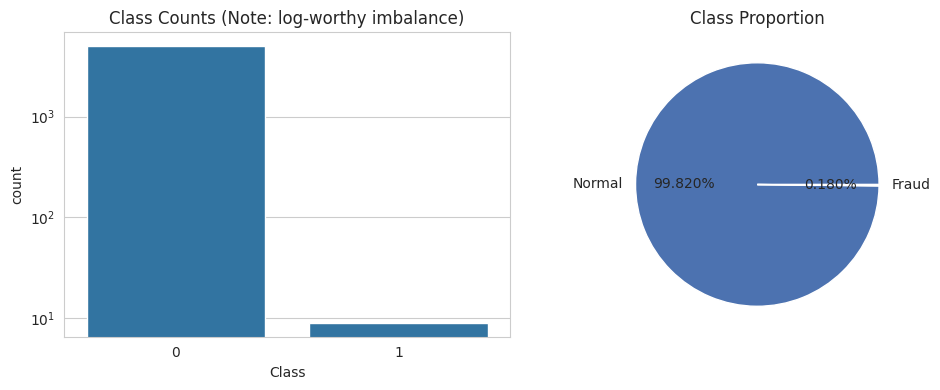

In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print(f"\nFraud rate: {class_pct[1]:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Class", data=df, ax=axes[0])
axes[0].set_title("Class Counts (Note: log-worthy imbalance)")
axes[0].set_yscale("log")

axes[1].pie(class_counts, labels=["Normal", "Fraud"], autopct="%1.3f%%", colors=["#4C72B0", "#C44E52"])
axes[1].set_title("Class Proportion")
plt.tight_layout()
plt.show()


**Takeaway:** the severe imbalance (~0.17% fraud) is the central challenge of this project. Accuracy alone will be a misleading metric — a model predicting "not fraud" for every transaction would still score ~99.8% accuracy. Precision/recall/F1/AUC-PR are addressed in Sprint 3; this sprint focuses on establishing correct data understanding and a baseline.


## 3. Feature Distributions — `Amount` and `Time`

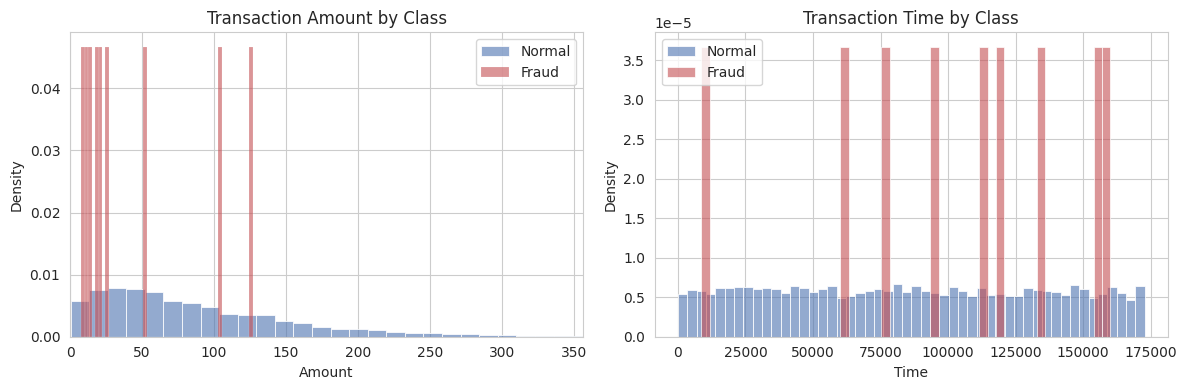

        count       mean        std   min      25%     50%       75%     max
Class                                                                       
0      5000.0  90.316204  74.435106  0.37  36.2475  71.175  125.5925  645.68
1         9.0  42.558889  43.976021  7.93  13.4300  21.390   52.3800  126.94


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["Class"] == 0]["Amount"], bins=50, color="#4C72B0", label="Normal", stat="density", ax=axes[0], alpha=0.6)
sns.histplot(df[df["Class"] == 1]["Amount"], bins=50, color="#C44E52", label="Fraud", stat="density", ax=axes[0], alpha=0.6)
axes[0].set_title("Transaction Amount by Class")
axes[0].set_xlim(0, df["Amount"].quantile(0.99))
axes[0].legend()

sns.histplot(df[df["Class"] == 0]["Time"], bins=50, color="#4C72B0", label="Normal", stat="density", ax=axes[1], alpha=0.6)
sns.histplot(df[df["Class"] == 1]["Time"], bins=50, color="#C44E52", label="Fraud", stat="density", ax=axes[1], alpha=0.6)
axes[1].set_title("Transaction Time by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].describe())


## 4. Correlation of `V1`–`V28` with `Class`

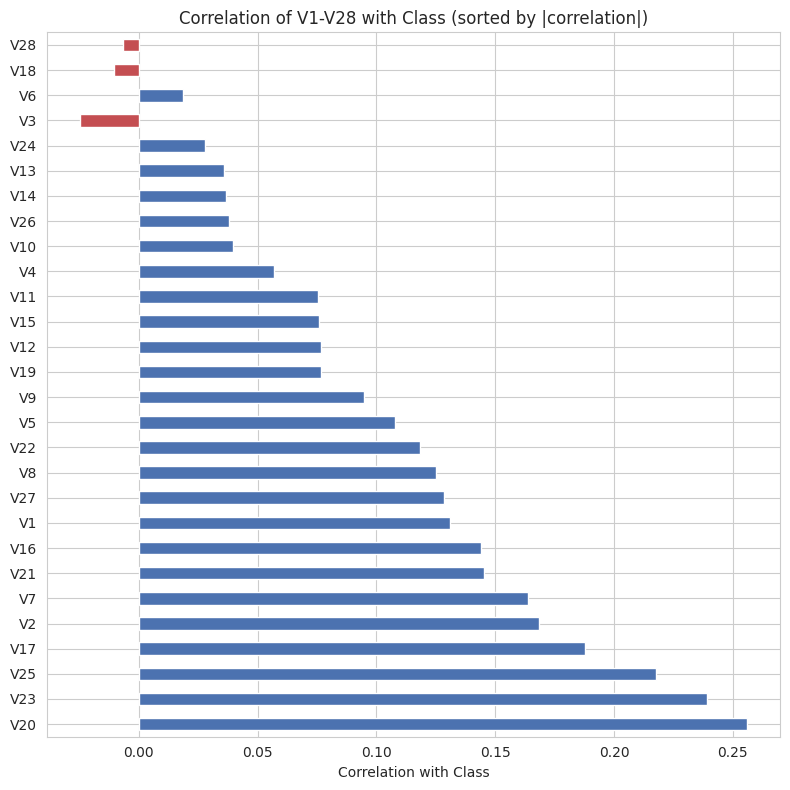

Top 5 most correlated features with Class:
V20    0.255836
V23    0.238995
V25    0.217711
V17    0.187941
V2     0.168351
Name: Class, dtype: float64


In [5]:
v_cols = [c for c in df.columns if c.startswith("V")]
corrs = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
corrs.plot(kind="barh", ax=ax, color=["#C44E52" if v < 0 else "#4C72B0" for v in corrs])
ax.set_title("Correlation of V1-V28 with Class (sorted by |correlation|)")
ax.set_xlabel("Correlation with Class")
plt.tight_layout()
plt.show()

print("Top 5 most correlated features with Class:")
print(corrs.head(5))


## 📝 EDA Summary

- Dataset is heavily imbalanced (~0.17% fraud) — this drives every modeling decision from here on (evaluation metrics, resampling in Sprint 3, threshold choice).
- No missing values or duplicates found in a clean copy of this dataset (verify against the real download — the check above reflects whichever data source was actually loaded).
- `Amount` and `Time` show visibly different distributions between fraud and normal transactions, suggesting they carry signal beyond the anonymized `V` features.
- A handful of `V` features show noticeably higher correlation with `Class` than the rest — worth prioritizing in feature engineering and later explainability (Sprint 3, SHAP).

**Next:** `02_data_preprocessing_feature_engineering.ipynb` — scaling, leak-free train/val/test split, and feature engineering.
